# Import

In [1]:
import torch
import transformers
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(device)

2024-12-18 13:45:28.517720: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-18 13:45:50.291000: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


0


In [2]:
cd ../

/sise/home/shistikk/IndicatorsOfResilience/code


/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
from qlatent.qmnli.qmnli_torch import *
from qlatent.qmnli.qmnli_torch import _QMNLI, QMNLI

In [4]:
# softmax_files = [False, True]
# softmax_files = [True]

def split_question(Q, index, scales, softmax, filters):
  result = []
  for s in scales:
    q = QCACHE(Q(index=index, scale=s))
    for sf in softmax:
      for f in filters:
        if sf:            
            qsf = QSOFTMAX(q,dim=[index[0], s])
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print((index, s),sf,f)
            result.append(qsf_f)
            
            qsf = QSOFTMAX(q,dim=s)
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(s,sf,f)
            result.append(qsf_f)
            
            qsf = QSOFTMAX(q,dim=index[0])
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(index[0],sf,f)
            result.append(qsf_f)
        else:
            qsf = QPASS(q,descupdate={'softmax':''})
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(s,sf,f)
            result.append(qsf_f)
  return result

def dict_pos_neg(pos, neg, w):
  return dict(dict_same_weight(1.0*w/len(pos),pos), **dict_same_weight(-1.0*w/len(neg),neg))

def print_permutations(q):
#     for q in Q1s:
    W = q._pdf['W']
    print(q._descriptor)
    for i, (kmap, w) in enumerate(zip(q._keywords_map, W)):
        context = q._context_template.format_map(kmap)
        answer = q._answer_template.format_map(kmap)
#         sexisem_score = sexisem_classifier(context.strip('.') + ' ' +answer)
        print(f'{i}.',context ,'->', answer, w)
#     break


frequency_weights:SCALE = {
    'never':-4,
    'very rarely':-3,
    'seldom':-2,
    'rarely':-2,
    'frequently':2,
    'often':2,
    'very frequently':3,
    'always':4,    
}
    
intensifiers_fraction_without_none:SCALE={
            "few":1,
            "some":2,
            "many":3,
            "most":4,
            "all":5,
        }
    
binary_frequency_weights = {k: 1 if v > 0 else -1 for k, v in frequency_weights.items()}
rbinary_frequency_weights = {k: -1 if v > 0 else 1 for k, v in frequency_weights.items()}
frequency_pos = [k for k, v in frequency_weights.items() if v > 0]
frequency_neg = [k for k, v in frequency_weights.items() if v < 0]

# Load Model

In [5]:
p = "typeform/distilbert-base-uncased-mnli"
mnli = pipeline("zero-shot-classification",device=0, model=p)
mnli.model_identifier = p

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
tokenizer = DistilBertTokenizer.from_pretrained("typeform/distilbert-base-uncased-mnli")
optimizer = AdamW(mnli.model.parameters(), lr=2e-5, weight_decay=0.01)

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/optimization.py:588: FutureWarning: This implemen

# Initial Gradients

In [6]:
# Print initial gradients (should be None)
print("Initial Gradients:")
for name, param in mnli.model.named_parameters():
    if param.grad is not None:
        print(f'Gradient for {name}: {param.grad}')
    else:
        print(f'Gradient for {name}: None')

Initial Gradients:
Gradient for distilbert.embeddings.word_embeddings.weight: None
Gradient for distilbert.embeddings.position_embeddings.weight: None
Gradient for distilbert.embeddings.LayerNorm.weight: None
Gradient for distilbert.embeddings.LayerNorm.bias: None
Gradient for distilbert.transformer.layer.0.attention.q_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.q_lin.bias: None
Gradient for distilbert.transformer.layer.0.attention.k_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.k_lin.bias: None
Gradient for distilbert.transformer.layer.0.attention.v_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.v_lin.bias: None
Gradient for distilbert.transformer.layer.0.attention.out_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.out_lin.bias: None
Gradient for distilbert.transformer.layer.0.sa_layer_norm.weight: None
Gradient for distilbert.transformer.layer.0.sa_layer_norm.bias: None
Gradient for di

# PHQ9 Questionnaire

## PHQ1

In [7]:
emo_pos=['little interest', 'no pleasure', 'displeasure', 'dissatisfaction']
emo_neg=['pleasure', 'satisfaction']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q1(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I had {index} in doing things.",
            answer_template="It is {frequency} correct.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":1,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Little interest or pleasure in doing things'
            },
            **kwargs
        )
PHQ9Q1s = split_question(PHQ9Q1,  
                      index=["index"],
                      scales=["frequency"],
                      softmax=[False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q1().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q1 =PHQ9Q1s[i]
# q1.run(mnli).report()

frequency False unfiltered
frequency False positiveonly


In [8]:
# q1.run(mnli)

In [9]:
# q1.effect_size_pos_neg()

## PHQ2

In [10]:
emo_pos=['down', 'depressed', 'hopeless']
emo_neg=['happy', 'hopeful', 'cheerful']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q2(QMNLI):
    def __init__(self, **kwargs ):
        super().__init__(
            context_template="Over the last 2 weeks, I have been feeling {index}.",
            answer_template="It is {frequency} correct.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":2,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling down, depressed or hopeless'
            },
            **kwargs
        )
PHQ9Q2s = split_question(PHQ9Q2,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q2().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q2 = PHQ9Q2s[i]
# q.run(mnli).report()


(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ3

In [11]:
emo_neg=['depressive', 'sad', 'gloom']
emo_pos=["benign", 'legitimate',]
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q3(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I {frequency} had trouble falling asleep.",
            answer_template="This sentence is {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":3,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble falling asleep, staying asleep, or sleeping too much'
            },
            **kwargs
        )
PHQ9Q3s = split_question(PHQ9Q3,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q3().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q3=PHQ9Q3s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ4

In [12]:
emo_pos=['tired', 'drained', 'fatigued']
emo_neg=['energized', 'refreshed', 'lively']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q4(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I feel {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":4,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling tired or having little energy'
            },
            **kwargs
        )
PHQ9Q4s = split_question(PHQ9Q4,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q4().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q4=PHQ9Q4s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ5

In [13]:
emo_pos=['poor appetite', 'been overeating']
emo_neg=['healthy appetite', 'satisfying appetite']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q5(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I had {index}",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":5,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Poor appetite or overeating'
            },
            **kwargs
        )
PHQ9Q5s = split_question(PHQ9Q5,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q5().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q5=PHQ9Q5s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ6

In [14]:
emo_pos=['I am a failure', 'I am a disappointment', 'I am underachieving', 'I let myself down', 'I let my family down']
emo_neg=['successful ', 'lucky', 'confident']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q6(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I feel {index}.",
            answer_template="It is {frequency} correct.",
            
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":6,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling bad about yourself - or that you’re a failure or have let yourself or your family down'
            },
            **kwargs
        )
PHQ9Q6s = split_question(PHQ9Q6,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q6().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q6=PHQ9Q6s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ7

In [15]:
emo_pos=["happy", 'joyful',]
emo_neg=['depressive', 'sad', 'gloom']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q7(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I {frequency} had trouble concentrating.",
            answer_template="This sentence is {index}.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":7,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble concentrating on things, such as reading the newspaper or watching television'
            },
            **kwargs
        )
PHQ9Q7s = split_question(PHQ9Q7,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q7().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q7=PHQ9Q7s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ8

In [16]:
emo_pos=['fidgetly', 'slowly']
emo_neg=['normally', 'naturally']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q8(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I move or speak {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":8,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Moving or speaking so slowly that other people could have noticed. Or, the opposite - being so fidgety or restless that you have been moving around a lot more than usual'
            },
            **kwargs
        )
PHQ9Q8s = split_question(PHQ9Q8,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q8().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q8=PHQ9Q8s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ9

In [17]:
emo_pos=['suicidal', 'self destructive', 'deadly']
emo_neg=['harmless', 'hopeful', 'positive']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q9(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have {index} thoughts.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":9,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Thoughts that you would be better off dead or of hurting yourself in some way'
            },
            **kwargs
        )
PHQ9Q9s = split_question(PHQ9Q9,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q9().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q9=PHQ9Q9s[i]
# q9.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# GAD7 Questionnaire

In [18]:
softmax_files = [True, False]

## GAD1

In [19]:
emo_pos=['nervous', 'anxious', 'on edge', 'agitated']
emo_neg=['calm', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q1(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been feeling {index}.",
            answer_template="It is {frequency} correct.",

           dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":1,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling nervous, anxious or on edge'
            },
            **kwargs
        )
GAD7Q1s = split_question(GAD7Q1,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q1().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q1s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.8216733932495117
Mean score unfiltered [-1.3333333333333333..1.3333333333333333]: -0.07089634984731674
Internal consistency (silhouette, correlation) for unfiltered: 0.7708303572211069
Internal consistency (Calinski&Harabasz)  for unfiltered: 58.457992287958234
Internal consistency (Davies&Bouldin) for unfiltered: 0.26954195950789744


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0004,0.1578,0.2158,0.1584,0.5068,0.6011,0.3316,0.5896
peaceful,0.0005,0.1308,0.2073,0.1613,0.3901,0.5266,0.2394,0.4964
relaxed,0.0001,0.0742,0.1262,0.0326,0.5145,0.6068,0.3782,0.5336
agitated,0.2300,0.2338,0.4034,0.4491,0.0545,0.1421,0.0288,0.0002
anxious,0.2563,0.2649,0.4574,0.5005,0.0940,0.1862,0.0633,0.0002
nervous,0.2630,0.2470,0.5056,0.5349,0.0112,0.0843,0.0055,0.0001
on edge,0.0024,0.1422,0.4565,0.3655,0.0754,0.2178,0.0450,0.0002


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['calm', 'peaceful', 'relaxed'] Alpha: 0.9817979086286314
['nervous', 'anxious', 'on edge', 'agitated'] Alpha: 0.9720546693055991
Global alpha: 0.7891972405009571


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


## GAD2

In [20]:
# emo_pos=['nervous', 'bothered', 'disturbed']
# emo_neg=['peaceful','calm', 'relaxed']
emo_pos = ['worried', 'troubled', 'disturbed']
emo_neg = ['peaceful','calm', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q2(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
              "Factor":"GAD7",
              "Ordinal":2,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Not being able to stop or control worrying'
            },
            **kwargs
        )

GAD7Q2s = split_question(GAD7Q2,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q2().get_filter_for_postive_keywords(['frequency'])
                      },
                      )

i = 0
q=GAD7Q2s[i]
q.run(mnli).report()

# q=GAD7Q2s[i]
# q.run(mnli2).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.02246403694152832
Mean score unfiltered [-1.3333333333333333..1.3333333333333333]: -0.0811571329832077
Internal consistency (silhouette, correlation) for unfiltered: 0.6494504125466022
Internal consistency (Calinski&Harabasz)  for unfiltered: 21.079026722849022
Internal consistency (Davies&Bouldin) for unfiltered: 0.42013666958429985


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0009,0.1956,0.3418,0.3426,0.3914,0.5482,0.2689,0.7359
peaceful,0.0463,0.1701,0.3290,0.3408,0.2513,0.4843,0.1170,0.6554
relaxed,0.0001,0.1301,0.2332,0.1722,0.5049,0.5928,0.4174,0.5673
disturbed,0.2659,0.1961,0.5153,0.3653,0.0624,0.1260,0.0217,0.0001
troubled,0.0806,0.1878,0.5558,0.4687,0.0082,0.0450,0.0094,0.0001
worried,0.4061,0.3284,0.7354,0.7124,0.0053,0.1191,0.0146,0.0000


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['peaceful', 'calm', 'relaxed'] Alpha: 0.9321628596113524
['worried', 'troubled', 'disturbed'] Alpha: 0.9568823758738467
Global alpha: 0.8828697954763577


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


## GAD3

In [21]:
emo_pos=['worried', 'anxious', 'nervous', 'bothered']
# emo_neg=['confident', 'tranquil']
emo_neg = ['calm', 'confident', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q3(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been {index} about different things.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":3,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Worrying too much about different things'
            },
            **kwargs
        )
GAD7Q3s = split_question(GAD7Q3,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q3().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q3s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.02682185173034668
Mean score unfiltered [-1.3333333333333333..1.3333333333333333]: -0.07052159309387207
Internal consistency (silhouette, correlation) for unfiltered: 0.5521351906417257
Internal consistency (Calinski&Harabasz)  for unfiltered: 10.029492407612883
Internal consistency (Davies&Bouldin) for unfiltered: 0.5471962642722494


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0023,0.2083,0.2725,0.2269,0.3203,0.5538,0.1388,0.3698
confident,0.0001,0.0046,0.0281,0.0030,0.8097,0.8170,0.5851,0.7757
relaxed,0.0035,0.2404,0.3086,0.2729,0.0868,0.2937,0.0234,0.0030
anxious,0.2894,0.3412,0.6403,0.6392,0.0435,0.1514,0.0113,0.0001
bothered,0.3230,0.4190,0.7189,0.6756,0.0005,0.0591,0.0002,0.0000
nervous,0.1888,0.3812,0.7273,0.6957,0.0005,0.0231,0.0001,0.0000
worried,0.2828,0.3788,0.6729,0.6775,0.0012,0.0568,0.0004,0.0000


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['calm', 'confident', 'relaxed'] Alpha: 0.37179676787113897
['worried', 'anxious', 'nervous', 'bothered'] Alpha: 0.996105204289095
Global alpha: 0.6575292719625178


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


## GAD4

In [22]:
emo_pos=['trouble', 'difficulty', ]
emo_neg=['no problem', 'an easy time']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q4(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been having {index} relaxing.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":4,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble relaxing'
            },
            **kwargs
        )
GAD7Q4s = split_question(GAD7Q4,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q4().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q4s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.018638134002685547
Mean score unfiltered [-2.0..2.0]: -0.14739559590816498
Internal consistency (silhouette, correlation) for unfiltered: 0.7763272050943755
Internal consistency (Calinski&Harabasz)  for unfiltered: 39.35655066056867
Internal consistency (Davies&Bouldin) for unfiltered: 0.22527911860507224


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
an easy time,0.0001,0.0656,0.1789,0.0784,0.6068,0.6334,0.3979,0.5440
no problem,0.0022,0.1324,0.2803,0.2493,0.7550,0.7564,0.5092,0.6705
difficulty,0.1131,0.2886,0.6037,0.6024,0.0038,0.0913,0.0013,0.0002
trouble,0.2804,0.4256,0.7624,0.7356,0.0003,0.0210,0.0002,0.0001


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['no problem', 'an easy time'] Alpha: 0.991111015988388
['trouble', 'difficulty'] Alpha: 0.9747384138537503
Global alpha: 0.92526779715985


## GAD5

In [23]:
emo_pos=['restless', 'agitated', 'nervous']
emo_neg=['calm', 'tranquil', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q5(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":5,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Being so restless that it is hard to sit still'
            },
            **kwargs
        )
GAD7Q5s = split_question(GAD7Q5,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q5().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q5s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.023859262466430664
Mean score unfiltered [-1.3333333333333333..1.3333333333333333]: -0.09312304854393005
Internal consistency (silhouette, correlation) for unfiltered: 0.8001856788237522
Internal consistency (Calinski&Harabasz)  for unfiltered: 59.339373426683075
Internal consistency (Davies&Bouldin) for unfiltered: 0.23060081559796658


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0009,0.1956,0.3418,0.3426,0.3914,0.5482,0.2689,0.7359
relaxed,0.0001,0.1301,0.2332,0.1722,0.5049,0.5928,0.4174,0.5673
tranquil,0.0001,0.0451,0.1621,0.1229,0.6209,0.6722,0.3757,0.8361
agitated,0.2923,0.2280,0.5647,0.5062,0.0034,0.0626,0.0068,0.0000
nervous,0.2559,0.2028,0.6428,0.5003,0.0021,0.0691,0.0055,0.0000
restless,0.3785,0.2199,0.6068,0.5817,0.0008,0.0175,0.0002,0.0000


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['calm', 'tranquil', 'relaxed'] Alpha: 0.9475353695886459


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


['restless', 'agitated', 'nervous'] Alpha: 0.9938819811461771
Global alpha: 0.9418939596763233


## GAD6

In [24]:
emo_pos=['annoyed', 'irritated', 'frustrated', 'bothered']
emo_neg=['calm', 'tranquil', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q6(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have become {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":6,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Becoming easily annoyed or irritable'
            },
            **kwargs
        )
GAD7Q6s = split_question(GAD7Q6,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q6().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q6s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


Query time: 0.028414249420166016
Mean score unfiltered [-1.0..1.0]: -0.06767677515745163
Internal consistency (silhouette, correlation) for unfiltered: 0.6085460974459371
Internal consistency (Calinski&Harabasz)  for unfiltered: 19.849134588816035
Internal consistency (Davies&Bouldin) for unfiltered: 0.5038786400749738


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0018,0.2351,0.3830,0.3669,0.2780,0.4785,0.1898,0.2597
peaceful,0.0805,0.2259,0.3995,0.4119,0.1806,0.4307,0.0831,0.2009
relaxed,0.0001,0.1403,0.2466,0.1525,0.4414,0.5647,0.3274,0.2432
tranquil,0.0003,0.1294,0.2685,0.2092,0.4427,0.5704,0.2304,0.2704
annoyed,0.2399,0.2377,0.5972,0.6115,0.0004,0.0283,0.0005,0.0000
bothered,0.5043,0.4784,0.9545,0.9020,0.0002,0.0172,0.0001,0.0000
frustrated,0.4164,0.2505,0.5702,0.5646,0.0002,0.0065,0.0002,0.0000
irritated,0.1566,0.1813,0.5903,0.5170,0.0008,0.0238,0.0019,0.0000


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


['calm', 'tranquil', 'peaceful', 'relaxed'] Alpha: 0.896352681191854
['annoyed', 'irritated', 'frustrated', 'bothered'] Alpha: 0.9746568387823196
Global alpha: 0.8569520683003609


## GAD7

In [25]:
emo_pos=['afraid', 'scared', 'anxious']
emo_neg=['calm', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q7(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been feeling {index} about upcoming events.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":7,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling afraid as if something awful might happen'
            },
            **kwargs
        )
GAD7Q7s = split_question(GAD7Q7,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q7().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q7s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency False positiveonly
Query time: 0.02051997184753418
Mean score unfiltered [-2.0..2.0]: -0.10318479686975479
Internal consistency (silhouette, correlation) for unfiltered: 0.8194761288818044
Internal consistency (Calinski&Harabasz)  for unfiltered: 66.21710302564661
Internal consistency (Davies&Bouldin) for unfiltered: 0.19619931181094857


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0018,0.1952,0.2882,0.2344,0.3715,0.5094,0.1531,0.2977
relaxed,0.0001,0.1280,0.2288,0.1326,0.3480,0.4755,0.1704,0.2562
afraid,0.2923,0.3760,0.6424,0.5865,0.0377,0.0617,0.0026,0.0002
anxious,0.2038,0.3160,0.5429,0.5156,0.0940,0.1765,0.0364,0.0004
scared,0.3028,0.3601,0.6458,0.5725,0.0342,0.1049,0.0034,0.0002


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


['calm', 'relaxed'] Alpha: 0.9835923380202576
['afraid', 'scared', 'anxious'] Alpha: 0.9894716211602888
Global alpha: -0.14969128895454736


# SOC13 Questionnaire

## SOC4

In [26]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
# kw_attitude_pos = ["indifferent to", "apathetic to"]
# kw_attitude_neg = ["caring about", "interested in"]
dict_attitude = dict_pos_neg(kw_attitude_pos,kw_attitude_neg, 1.0)


class SOCQ4(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="What goes around me is {index} to me.",
#         context_template = "I am {index} what goes around me.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":4,
                      "Original":"Do you have the feeling that you don’t really care what goes on around you? "
        },
        **kwargs,
    )
SOCQ4s = split_question(SOCQ4,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ4().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ4s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC5

In [27]:
kw_attitude_neg = ['surprised by','puzzled by', ]
kw_attitude_pos = ['expecting','anticipating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ5(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I am {frequency} {index} the behavior of people I thought I knew well.",
        answer_template="True.", 
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":5,
                      "Original":"Has it happened in the past that you were surprised by the behavior of people whom you thought you knew well? "
        },
        **kwargs,
    )
SOCQ5s = split_question(SOCQ5,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ5().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ5s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC6

In [28]:
kw_attitude_neg = ["disappointed", 'failed']
kw_attitude_pos = ["supported", "helped"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ6(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="People whom I counted on {frequency} {index} me.",
        answer_template="True.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":6,
                      "Original":"Has it happened that people whom you counted on disappointed you? "
        },
        **kwargs,
    )
SOCQ6s = split_question(SOCQ6,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ6().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ6s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC8

In [29]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ8(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="My life are {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":8,
                      "Original":"Until now your life has had: "
        },
        **kwargs,
    )
SOCQ8s = split_question(SOCQ8,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ8().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ8s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC9

In [30]:
kw_attitude_neg = ["unfairly", "unjustly", "with discrimination", "unequally"]
kw_attitude_pos = ["fairly", "justly", "equally"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ9(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I feel that I am being treated {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":9,
                      "Original":"Do you have the feeling that you’re being treated unfairly? "
        },
        **kwargs,
    )
SOCQ9s = split_question(SOCQ9,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ9().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ9s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC12

In [31]:
kw_attitude_neg = ["helpless", "hopeless", 'powerless']
kw_attitude_pos = ["easy", "comfortable", "relaxed"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

dict_index2 = dict_pos_neg(['know'], ["don't know"], 1.0)


class SOCQ12(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__( 
        context_template="In unfamiliar situation I feel {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":12,
                      "Original":"Do you have the feeling that you’re in an unfamiliar situation and don’t know what to do?"
        },
        **kwargs,
    )
SOCQ12s = split_question(SOCQ12,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ12().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ12s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC16

In [32]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ16(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="Things I do every day are {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":16,
                      "Original":"Doing the things you do every day is: "
        },
        **kwargs,
    )
SOCQ16s = split_question(SOCQ16,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ16().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ16s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC19

In [33]:
kw_attitude_pos = ["clear", "coherent", 'logical', 'comprehensible']
kw_attitude_neg = ["mixed-up", "confounded"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ19(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I have {index} feelings and ideas.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":19,
                      "Original":"Do you have very mixed-up feelings and ideas? "
        },
        **kwargs,
    )
SOCQ19s = split_question(SOCQ19,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ19().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ19s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC21

In [34]:
# kw_attitude_neg = ["unwanted", 'undesired']
# kw_attitude_pos = ['joyful', 'good',]
kw_attitude_pos = ['face', 'confront', 'acknowledge', 'process', 'accept']
kw_attitude_neg = [ 'ignore', 'avoid', 'dismiss']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ21(QMNLI):
  """
  """

  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I have {index} feelings.",
        context_template="I have feelings inside I would like to {index}.",
        answer_template="It is {frequency} correct.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":21,
                      "Original":"Does it happen that you have feelings inside you would rather not feel? "
        },
        **kwargs,
    )
SOCQ21s = split_question(SOCQ21,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ21().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ21s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC25

In [35]:
kw_attitude_neg = ["loser", "sad sack"]
kw_attitude_pos = ["winner", "success"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ25(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I’m a {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":25,
                      "Original":"Many people—even those with a strong character—sometimes feel like sad sacks (losers) in certain situations. How often have you felt this way in the past? "
        },
        **kwargs,
    )
SOCQ25s = split_question(SOCQ25,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ25().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ25s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC26

In [36]:
kw_attitude_pos = ["estimate in proportion", "judge in proportion",]
kw_attitude_neg = ["overestimate","misjudge",'underestimate']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ26(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I {index} the importence of something that happened.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":26,
                      "Original":"When something happened‚ you have generally found that: you overestimated or underestimated its importance, you saw things in the right proportion"
        },
        **kwargs,
    )
SOCQ26s = split_question(SOCQ26,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ26().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ26s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC28

In [37]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ28(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="The things I do in my daily life are {index} to me.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":28,
                      "Original":"How often do you have the feeling that there’s little meaning in the things you do in your daily life? "
        },
        **kwargs,
    )
SOCQ28s = split_question(SOCQ28,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ28().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ28s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC29

In [38]:
kw_attitude_neg = ["out of control", "uncontrollable", 'unmanageable' ]
kw_attitude_pos = ["contained", "collected", 'controlled']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ29(QMNLI):
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I feel that my feelings are {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":29,
                      "Original":"How often do you have feelings that you’re not sure you can keep under control? "
        },
        **kwargs,
    )
SOCQ29s = split_question(SOCQ29,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ29().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ29s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# Neuroticism

## BIG5   13

In [39]:
kw_attitude_pos = ['stressed', 'worried', 'distressed']
kw_attitude_neg = ['calm', 'composed']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class BIG5Q13(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template = "I feel {index} about things",
            answer_template = "It is {frequency} correct.",
            dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
            descriptor = {"Questionnair":"BIG5",
              "Factor":"Neuroticism",
              "Ordinal":13,
            "Original":"I am easily stressed and worry about things."
            },
            **kwargs
        )
BIG5Q13s = split_question(BIG5Q13,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly":BIG5Q13().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q=BIG5Q13s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.11972737312316895
Mean score unfiltered [-2.0..2.0]: -0.12010014057159424
Internal consistency (silhouette, correlation) for unfiltered: 0.7897736836553736
Internal consistency (Calinski&Harabasz)  for unfiltered: 49.23774702359095
Internal consistency (Davies&Bouldin) for unfiltered: 0.24194005232988328


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0013,0.2192,0.2687,0.2706,0.3142,0.4514,0.1581,0.6829
composed,0.0001,0.1324,0.2190,0.1296,0.5224,0.6240,0.3465,0.4729
distressed,0.6964,0.4041,0.6807,0.6768,0.0001,0.0028,0.0001,0.0000
stressed,0.5306,0.3278,0.6537,0.6236,0.0001,0.0190,0.0001,0.0000
worried,0.6682,0.4276,0.7453,0.7437,0.0001,0.0483,0.0002,0.0000


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['calm', 'composed'] Alpha: 0.8304704821879452
['stressed', 'worried', 'distressed'] Alpha: 0.995800428430908
Global alpha: 0.311800766472862


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


## BIG5   14

In [40]:
kw_attitude_pos = ['distressed', 'upset', 'volatile']
kw_attitude_neg = ['calm', 'composed', 'collected']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class BIG5Q14(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template = "I feel emotionally {index}",
            answer_template = "It is {frequency} correct.",
            dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
            descriptor = {"Questionnair":"BIG5",
              "Factor":"Neuroticism",
              "Ordinal":14,
            "Original":"I am easily upset and prone to mood swings."
            },
            **kwargs
        )
BIG5Q14s = split_question(BIG5Q14,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly":BIG5Q14().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q=BIG5Q14s[i]
q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
Query time: 0.021491527557373047
Mean score unfiltered [-1.3333333333333333..1.3333333333333333]: -0.08758284896612167
Internal consistency (silhouette, correlation) for unfiltered: 0.7843252344212962
Internal consistency (Calinski&Harabasz)  for unfiltered: 41.88156755228169
Internal consistency (Davies&Bouldin) for unfiltered: 0.2351459519186339


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
calm,0.0001,0.1415,0.2235,0.1366,0.4652,0.5435,0.3570,0.4540
collected,0.1352,0.2056,0.3564,0.3278,0.1692,0.3928,0.1318,0.1342
composed,0.0012,0.1522,0.2825,0.2500,0.3981,0.5105,0.2928,0.3457
distressed,0.6828,0.3743,0.7104,0.7192,0.0002,0.0249,0.0009,0.0000
upset,0.6952,0.3387,0.7063,0.7165,0.0008,0.0575,0.0124,0.0001
volatile,0.6664,0.3640,0.7638,0.7112,0.0028,0.1000,0.0211,0.0002


index = ['index']
{'frequency', 'index'} {'frequency'} {'index'}
[]
['calm', 'composed', 'collected'] Alpha: 0.7574930250741947
['distressed', 'upset', 'volatile'] Alpha: 0.9989413771977613
Global alpha: 0.8932945982683231


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:394: FutureWarning: The provided callable <function mean at 0x7f24340d9580> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


# Validation of Translation

In [41]:
from pathlib import Path
import warnings
from sentence_transformers import SentenceTransformer, util
from collections import defaultdict

In [42]:
import gc
gc.collect()
torch.cuda.empty_cache()

0

In [43]:
sentence_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
cola = pipeline("text-classification","mrm8488/deberta-v3-small-finetuned-cola", device=device)

import os
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu

def linguistic_acceptabilities(q, index, scale,question_name, student_id, output_path=Path(''), save_to_file=False):
    score_by_cola_lst=[]
    score_of_semantic_distance_lst=[]
    score_by_bleu_lst=[]
    kmap_lst=[]
    question_name_lst=[]
    description = q._descriptor
    strFactor=description['Factor']
    strOrdinal=str(description.get('Ordinal', 0))
    ##cleaning the string to get the original question
    strOriginal= description['Original']
    strOriginal = 'none' if strOriginal is None else strOriginal
    strOriginal=strOriginal.replace(strFactor,'',1)
    strOriginal=strOriginal.replace(strOrdinal,'',1)
    strOriginal=strOriginal.replace('.','',1)
    strOriginal=strOriginal.strip() #the original question
    rows = []
    
    partial_internal_consistency = partial(q.internal_consistency, filter={}, index=index , scale=scale)
    try:
        silhouette_score = partial_internal_consistency(measure='silhouette_score', metric='correlation')
    except Exception as e:
        print(e)
        print('silhouette_score is set to -1')
        silhouette_score = -1
        
    if hasattr(q, 'linguistic_acceptability'):
        q.linguistic_acceptability['silhouette_score'] = silhouette_score
        return q.linguistic_acceptability

    for kmap in q._keywords_map:
        score = {}
        score['question_name'] = question_name
        context = q._context_template.format_map(kmap)
        answer = q._answer_template.format_map(kmap)
        score['original_question'] = strOriginal


        cola_score = cola(context +" "+ answer)[0].get('score')
        score['cola_score'] = cola_score
        score['param'] = kmap
        strPermutation= context +" "+ answer
        # sentences = [context +" "+ answer]
        score['question_permutation'] = strPermutation
        #Compute embedding for both lists
        embeddings1 = sentence_embedding_model.encode(strOriginal, convert_to_tensor=True)
        embeddings2 = sentence_embedding_model.encode(strPermutation, convert_to_tensor=True)

        #Compute cosine-similarities
        cosine_scores = util.cos_sim(embeddings1, embeddings2)
        score['semantic_similarity'] = cosine_scores.item()

        score['silhouette_score'] = silhouette_score
        rows.append(score)


    filename = output_path / 'linguistic_acceptabilities.csv'
    df = pd.DataFrame(rows)
    df['student_id'] = student_id
    df = df[['student_id', 'question_name','original_question', 'param','question_permutation','cola_score','semantic_similarity','silhouette_score']]
    if save_to_file:
        if filename.exists():
            df.to_csv(filename, index=False, header=None, mode='a', encoding='utf-8-sig')
        else:
            df.to_csv(filename, index=False, encoding='utf-8-sig')
#     print(f"Linguistic acceptabilities saved in {filename}")
    q.linguistic_acceptability = df
    return df

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [44]:
def question_attributes(q):
    score = {}
    score['questionnair']=q._descriptor['Questionnair']
    score['factor']=q._descriptor['Factor']
    score['ordinal']=q._descriptor['Ordinal']
    score['scale']=q._descriptor['scale']
    score['index']=q._descriptor['index']
    score['filter']=q._descriptor['filter']
    score['softmax'] = q._descriptor['softmax']
    score["original"] = q._descriptor['Original']
    score['Q'] = f"{score['questionnair']}{score['factor']}{score['ordinal']}"
    score['context_template'] = q._context_template
    score['answer_template'] = q._answer_template
    score['dimensions'] = q._dimensions
    score['model'] = q.model.model_identifier if q.model else ""
    return score

def get_question_features(q, student_id='student_id', output_path=Path(''), save_to_file=False):
    score = question_attributes(q)
    score['mean_score'] = q.mean_score()
    index= q._index
    scale= q._scale
    linguistic_df = linguistic_acceptabilities(q, index=index, scale=scale,question_name=score['Q'], student_id=student_id,
                                               output_path=output_path, save_to_file=save_to_file)
    row = linguistic_df[['cola_score','silhouette_score']].mean(axis=0)
    row_dict = dict(row)
    row_dict['semantic_similarity'] = linguistic_df['semantic_similarity'].quantile(0.75)
    score = score | row_dict
    return score

def extract_epoch(model_path):
    if 'epoch-' in model_path.name:
        i = model_path.name.find('epoch-')
        j = model_path.name.find('_', i)
        if j > 0:
            epoch = int(model_path.name[i+len('epoch-'):j])
        else:
            epoch = int(model_path.name[i+len('epoch-'):])
        
    elif 'checkpoint-' in model_path.name:
        i = model_path.name.find('checkpoint-')
        j = model_path.name.find('_', i)
        if j > 0:
            epoch = int(model_path.name[i+len('checkpoint-'):j])
        else:
            epoch = int(model_path.name[i+len('checkpoint-'):])
    else:
        epoch = 0
    return epoch

def extract_run(model_path):
    try:
        if 'run' in model_path.name:
            for part in model_path.name.split('_'):
                if 'run' in part:
                    return int(part.replace('run', ''))
        else:
            return -1
    except Exception as e:
        print(e)
        return -1

import json

def get_mnli_score(checkpoint_path):
    mnli_score_path = checkpoint_path / 'all_results.json'
    if not mnli_score_path.exists():
        mnli_score_path = checkpoint_path.parent / (checkpoint_path.name + '_mnli_eval') / 'all_results.json'
    if mnli_score_path.exists():
        with open(mnli_score_path) as f:
            return json.load(f)["eval_accuracy"]
    else:
        return -1
    
# def run_questions(questions, mnli_base, mnli_checkpoint, checkpoint, train_process, fintune_dataset, q_range=[5, 0]):
#     if mnli_base is not mnli_checkpoint:
#         take_classifier(mnli_base, mnli_checkpoint)
#     rows = []
#     for q_raw in tqdm(questions):
# #         qname = q_identifier(q)
# #         print(qname)
#         print(q_raw, mnli_checkpoint.model_identifier)
#         q = q_raw.run(mnli_checkpoint)
#         score = get_question_features(q)
#         score['epoch'] = extract_epoch(checkpoint)
#         score['train_process'] = train_process
#         score['dataset'] = fintune_dataset
#         score['run'] = extract_run(checkpoint.parent)
#         score['mnli_score'] = get_mnli_score(checkpoint)
#         score['range'] = (q._weights_flat.min(), q._weights_flat.max())
#         score['ASI_score'] = np.interp(score['mean_score'], [q._weights_flat.min(), q._weights_flat.max()], q_range)
#         rows.append(score)
#         gc.collect()
#         torch.cuda.empty_cache()
#     return rows


def run_questions(questions, mnli_checkpoint, train_process, fintune_dataset, q_range=[5, 0]):    
    rows = []
    checkpoint = Path(mnli_checkpoint.model_identifier)
    for q_raw in tqdm(questions):
        T = time.time()
        q = q_raw.run(mnli_checkpoint)
#         print('run question:', time.time() - T, 'sec')
        T = time.time()
        score = get_question_features(q)
#         print('get features:', time.time() - T, 'sec')
        score['epoch'] = extract_epoch(checkpoint)
        score['train_process'] = train_process
        score['dataset'] = fintune_dataset
        score['run'] = extract_run(checkpoint.parent)
        score['mnli_score'] = get_mnli_score(checkpoint)
        score['range'] = (q._weights_flat.min(), q._weights_flat.max())
        score['ASI_score'] = np.interp(score['mean_score'], [q._weights_flat.min(), q._weights_flat.max()], q_range)
        rows.append(score)
        gc.collect()
        torch.cuda.empty_cache()
    return rows


def calc_scores(questions, checkpoint, output_path, train_process, fintune_dataset, q_range=[5, 0]):
    fix_config(checkpoint)
    mnli_checkpoint = pipeline("zero-shot-classification", str(checkpoint), device=device)
    mnli_checkpoint.model_identifier = str(checkpoint)
    rows = run_questions(questions, mnli_checkpoint, train_process, fintune_dataset=fintune_dataset, q_range=q_range)
    return rows

def add_epochs_to_rows(rows, mlm_epoch, mnli_checkpoint):
    for score in rows:
        score['mlm_epoch'] = mlm_epoch
        score['mnli_checkpoint'] = mnli_checkpoint
    return rows


def write_to_csv(rows, output_path):
    old_score_hostile_df = pd.DataFrame(rows)
    if output_path.exists():
        old_score_hostile_df.to_csv(output_path, index=False, header=None, mode='a')
    else:
        old_score_hostile_df.to_csv(output_path, index=False)

def fix_config(checkpoint):
    if checkpoint.exists():
        with open(checkpoint / 'config.json') as f:
            d1 = json.load(f)
        d1['id2label'] = {'0': 'entailment', '1': 'neutral', '2': 'contradiction'}
        d1['label2id'] = {'contradiction': 2, 'entailment': 0, 'neutral': 1}
        with open(checkpoint / 'config.json', 'w') as f:
            json.dump(d1, f)
    else:
        print(checkpoint, '#### Not exists ####')
        
def calc_for_all_models(Qs, q_range= [5, 0]):
    all_rows = []
    for p in tqdm(mnli_pipelines):
        print(p)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            rows = calc_scores(Qs, Path(p),  Path(p), '->'.join(['base']), 'hostile',
                               use_base_model=False, q_range=q_range)
            rows = add_epochs_to_rows(rows, 0, 0)
            all_rows += rows
    return pd.DataFrame(all_rows)

In [45]:
result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path)

In [46]:
pwd

'/sise/home/shistikk/IndicatorsOfResilience/code'

In [47]:
mnli_pipelines = [
                  'typeform/distilbert-base-uncased-mnli',
                  'ishan/distilbert-base-uncased-mnli',
                  'typeform/mobilebert-uncased-mnli',
                  'typeform/squeezebert-mnli',
                  'cross-encoder/nli-roberta-base',
                  'cross-encoder/nli-deberta-base',
                  'cross-encoder/nli-distilroberta-base',
                  'cross-encoder/nli-MiniLM2-L6-H768',
                  'navteca/bart-large-mnli',
                  'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
                  'joeddav/bart-large-mnli-yahoo-answers',
                  'Narsil/deberta-large-mnli-zero-cls',
                  'seduerr/paiintent',
                  'microsoft/deberta-large-mnli',
                  'microsoft/deberta-base-mnli',
                  'ishan/bert-base-uncased-mnli',
                  'Alireza1044/albert-base-v2-mnli',
                  'Intel/bert-base-uncased-mnli-sparse-70-unstructured',
#                   'yoshitomo-matsubara/bert-large-uncased-mnli',
#                   'yoshitomo-matsubara/bert-base-uncased-mnli',
#                   'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
                  'valhalla/distilbart-mnli-12-6',
]

## Run Questions

In [48]:
questions = GAD7Q1s + GAD7Q2s  + GAD7Q3s + GAD7Q4s + GAD7Q5s + GAD7Q6s + GAD7Q7s + PHQ9Q1s + PHQ9Q2s + PHQ9Q3s + PHQ9Q4s + PHQ9Q5s + PHQ9Q6s + PHQ9Q7s + PHQ9Q8s + PHQ9Q9s
questions += SOCQ4s + SOCQ5s + SOCQ6s + SOCQ8s + SOCQ9s + SOCQ12s + SOCQ16s + SOCQ19s + SOCQ21s + SOCQ25s + SOCQ26s + SOCQ28s + SOCQ29s
questions += BIG5Q13s + BIG5Q14s
# questions = SOCQ6s
update = True

output_path = result_path / f'phq_gad_soc_neuro_mnli_v4.csv'
# [str(a) for a in Path('mnli_models/').glob('*_mnli')]
pipelines = mnli_pipelines

if output_path.exists():
    temp_df = pd.read_csv(output_path)
    indexes = temp_df.groupby(['model', 'Q']).count().index.values
    used_models = defaultdict(set)
    for k, v in indexes:
        used_models[k].add(v)
else:
    used_models = {}


for p in tqdm(pipelines):
    print(p)
#     if get_mnli_score(Path(p)) < 0.7 and p not in mnli_pipelines:
#         print('Skip:', p)
#         continue
    with warnings.catch_warnings():
        try:
            warnings.simplefilter("ignore")        
            if p in used_models and not update:
                pipline_questions = []
                for q in questions:
                    if question_attributes(q)['Q'] not in used_models[p]:
                        pipline_questions.append(q)
                    else:
                        print('skip', p, question_attributes(q)['Q'])
            else:
                pipline_questions = questions

            rows = calc_scores(pipline_questions, Path(p),  output_path, '->'.join(['base']), 'hostile',)
            rows = add_epochs_to_rows(rows, 0, 0)
            write_to_csv(rows, output_path) 
            gc.collect()
            torch.cuda.empty_cache()
        except Exception as e:
            print(e)

            
df = pd.read_csv(output_path)
df = df.drop_duplicates(subset=['filter','softmax','model','Q'], keep='last')
df.to_csv(output_path, index=False)

  0%|          | 0/19 [00:00<?, ?it/s]The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


typeform/distilbert-base-uncased-mnli
typeform/distilbert-base-uncased-mnli #### Not exists ####


The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.

  0%|          | 0/242 [00:00<?, ?it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

  1%|          | 3/242 [00:05<06:33,  1.64s/it]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



  2%|▏         | 4/242 [00:06<06:15,  1.58s/it]

...


100%|█████████▉| 241/242 [01:05<00:00,  3.90it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



100%|██████████| 242/242 [01:05<00:00,  3.69it/s]


0

100%|██████████| 19/19 [24:23<00:00, 77.01s/it]


In [49]:
import pingouin as pg

In [50]:
def load_results(csv_path, softmax, positiveonly, value='ASI_score', index='model', colums='Q'):
    df = pd.read_csv(csv_path)
    df['model'] = df['model'].str.replace('/dt/puzis/cnalab/maor/', '')
    if df['softmax'].isna().sum() > 0:
        softmax_filter = df['softmax'].isna()
    else:
        softmax_filter = df['softmax'] == ''
    if softmax:
        df = df[df['softmax'] == str(softmax)]
    else:
        df = df[softmax_filter]
    if value != 'silhouette_score':
        pass
    else:
        df = df[df['silhouette_score'] > -1]
    if positiveonly:
        df = df[df['filter']=="positiveonly"]
    else:
        df = df[df['filter']=="unfiltered"]
    results_df = pd.pivot_table(df, values=value, index=index, columns=colums, aggfunc='mean')
    return results_df


def get_factor_sub_features(factor, data_df):
    factor = factor if isinstance(factor, list) else [factor]
    feature_subset = []
    for subset in factor:
        for c in data_df.columns:
            if str(subset) in c:
#                 if c[c.find(subset):].replace(subset, '').isnumeric():
                feature_subset.append(c)
    return list(set(feature_subset))

## Validation

In [52]:
softmax_soc=['index', 'frequency'] # False, ['index'], ['frequency'], ['index', 'frequency']
# softmax_gad=['emotion', 'intensifier'] # False, ['emotion'], ['intensifier'], ['emotion', 'intensifier']
# softmax_asi=['frequency']
# softmax_asi=False
positiveonly=True

lr = 2e-5
soc_factors = ['Comprehensibility', 'Manageability', 'Meaningfulness', ]
big_factors = ['Neuroticism']
# asi_factors = ['H', 'BI', 'BP', 'BG', 'B']
q_path = result_path / f'phq_gad_soc_neuro_mnli_v4.csv'
# all_filters = [softmax_asi]
# all_factors = ['H', 'B']
gad_factors = ['GAD7']
phq_factors = ['PHQ9']

In [53]:
cols = ['semantic_similarity', 'cola_score', 'silhouette_score']

results = []
for softmax_filter in [softmax_soc]:
    q_res = [load_results(q_path,softmax=softmax_filter,positiveonly=False, value=v).mean(axis=0) for v in cols]
    results.append(pd.concat(q_res, axis=1))
    
liguestic_acceptability_df = pd.concat(results, axis=0)
liguestic_acceptability_df.columns=['semantic_similarity', 'cola_score', 'silhouette_score']
liguestic_acceptability_df.to_csv(result_path / 'qmlm_liguestic_acceptability.csv', index=False)
liguestic_acceptability_df.sort_values('silhouette_score')

,semantic_similarity,cola_score,silhouette_score
Q,,,
PHQ9PHQ98,0.686993,0.796706,0.485614
PHQ9PHQ99,0.485451,0.773650,0.493626
SOCComprehensibility5,0.684450,0.959107,0.518589
SOCManageability29,0.605033,0.729215,0.547935
PHQ9PHQ95,0.671451,0.680076,0.619797
PHQ9PHQ93,0.631983,0.924723,0.636161
SOCComprehensibility21,0.610296,0.713771,0.648970
GAD7GAD73,0.625612,0.834006,0.651722
SOCManageability6,0.638795,0.929842,0.665900


In [54]:
liguestic_acceptability_df.mean()

semantic_similarity    0.571346
cola_score             0.835336
silhouette_score       0.690609
dtype: float64

In [55]:
liguestic_acceptability_df.std()

semantic_similarity    0.111055
cola_score             0.105617
silhouette_score       0.085064
dtype: float64

In [56]:
def get_factor_sub_features(factor, data_df):
    feature_subset = []
    for subset in factor:
        feature_subset += [c for c in data_df.columns if subset in c]
    return list(set(feature_subset))

In [57]:
value='mean_score'

results = []
for softmax_filter in [softmax_soc]:
# for softmax_filter in [softmax_asi]:
    results.append(load_results(q_path,softmax=softmax_filter,positiveonly=positiveonly, value=value))
    
data_df = pd.concat(results, axis=1)

print('Cronbach Alpha:')
for subset in gad_factors + phq_factors + big_factors:
# for subset in asi_factors:
    feature_subset = [c for c in data_df.columns if subset in c]
    alpha = pg.cronbach_alpha(data=data_df[feature_subset])
    print(f'{subset}, Alpha:, {alpha}')

asi_feature_subset = get_factor_sub_features(soc_factors, data_df)
alpha = pg.cronbach_alpha(data=data_df[asi_feature_subset])
print(f'SOC, Alpha:, {alpha}')

Cronbach Alpha:
GAD7, Alpha:, (0.9559700249593368, array([0.911, 0.983]))
PHQ9, Alpha:, (0.9488351374700115, array([0.898, 0.98 ]))
Neuroticism, Alpha:, (0.9680836286457772, array([0.905, 0.989]))
SOC, Alpha:, (0.8742808503745887, array([0.755, 0.95 ]))


In [58]:
for subset in ['Manageability']:
    feature_subset = [c for c in data_df.columns if subset in c]
#     subset_df = data_df[feature_subset].drop(subset, axis=1)
    subset_df = data_df[feature_subset]
    alpha = pg.cronbach_alpha(data=subset_df)
    print(subset, 'Alpha:', alpha)
    for feature in subset_df.columns:
        sub = [c for c in subset_df.columns if c != feature]
        alpha = pg.cronbach_alpha(data=subset_df[sub])
        print('without:', feature, 'Alpha:', alpha)

Manageability Alpha: (0.6468894316045628, array([0.225, 0.868]))
without: SOCManageability25 Alpha: (0.4357218179222665, array([-0.34 ,  0.795]))
without: SOCManageability29 Alpha: (0.45808789027067254, array([-0.287,  0.803]))
without: SOCManageability6 Alpha: (0.8511873998569456, array([0.647, 0.946]))
without: SOCManageability9 Alpha: (0.5716273529926702, array([-0.017,  0.844]))


In [59]:
value='mean_score'

results = []
for softmax_filter in [softmax_soc]:
# for softmax_filter in [softmax_asi]:
    results.append(load_results(q_path,softmax=softmax_filter,positiveonly=positiveonly, value=value))
    
data_df = pd.concat(results, axis=1)

filterd_df = pd.DataFrame()
for factor in gad_factors + phq_factors + big_factors:
# for factor in asi_factors:
    feature_subset = get_factor_sub_features([factor], data_df)
    filterd_df[factor] = data_df[feature_subset].mean(axis=1)

soc_feature_subset = get_factor_sub_features(soc_factors, data_df)
filterd_df['SOC13'] = data_df[soc_feature_subset].mean(axis=1)
# asi_feature_subset = get_factor_sub_features(asi_factors, data_df)
# filterd_df['ASI'] = data_df[asi_feature_subset].mean(axis=1)

filterd_df.rcorr(method='spearman')

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/pingouin/correlation.py:1116: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat_upper = mat_upper.applymap(replace_pval)


,GAD7,PHQ9,Neuroticism,SOC13
GAD7,-,***,***,***
PHQ9,0.964,-,***,**
Neuroticism,0.9,0.935,-,**
SOC13,-0.785,-0.742,-0.699,-


# Train and Validate

In [12]:
from datasets import load_dataset
dataset = load_dataset('multi_nli')

validation_dataset = dataset['validation_matched']

In [73]:
questions_gad = [
    GAD7Q1s, GAD7Q2s, GAD7Q3s, GAD7Q4s, GAD7Q5s, GAD7Q6s, GAD7Q7s,
]

questions_soc = [
    SOCQ4s, SOCQ5s, SOCQ6s, SOCQ8s, SOCQ9s, SOCQ12s, SOCQ16s, SOCQ19s,
    SOCQ21s, SOCQ25s, SOCQ26s, SOCQ28s, SOCQ29s,
]

questions_phq = [PHQ9Q1s , PHQ9Q2s , PHQ9Q3s , PHQ9Q4s , PHQ9Q5s , PHQ9Q6s , PHQ9Q7s , PHQ9Q8s , PHQ9Q9s]

In [53]:
# questions_pg = questions_phq + questions_gad

In [54]:
def train(questions, epoch, i):
    mnli.model.train()
    mnli.model_identifier = p + f'_e{epoch}'
    
    for Q in questions:
        q = Q[i]
        q.run(mnli)
#         mean_score = 1 - q.mean_score()
#         mean_score = mean_score.to(device) 
        effect_size = q.effect_size() * -1
        effect_size = effect_size.to(device)
#         effect_size_pos_neg = q.effect_size_pos_neg() * -1
#         effect_size_pos_neg = effect_size_pos_neg.to(device)        
        
        optimizer.zero_grad()
#         mean_score.backward()
        effect_size.backward()
#         effect_size_pos_neg.backward()
        optimizer.step()
        

In [46]:
def validate(questions, i, key):
#     total_mean_score = 0
    total_effect_size = 0
    mnli.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(mnli)
#             total_mean_score += q.mean_score()
#             total_effect_size += q.effect_size()
            total_effect_size += q.effect_size_pos_neg()
        
#     avg_val_mean_score = total_mean_score / len(questions)
    avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key].append(avg_val_mean_score)
#     print('validate average - mean score: {:.4f}'.format(total_mean_score/len(questions)))

In [47]:
def nli_accuracy(model, validation_data):
    correct = 0
    total = 0
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    mean_scores['nli'].append(accuracy)
#     return accuracy

In [60]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        if key == 'nli':
            range_plot = list(range(0, 51, 5))
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            range_plot = range(epochs)
            plt.title(f'{titles[idx]} Effect Size Pos-Neg')
            plt.ylabel('Effect Size Pos-Neg')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend()

    plt.tight_layout()
    plt.show()

In [55]:
epochs = 50
mean_scores = {
    'validation_gad': [],
    'validation_soc': [],
    'validation_phq': [],
    'nli' : []
}

for epoch in tqdm(range(epochs), desc="Training Epochs"):
#     print('Epoch: {}'.format(epoch))
    train(questions_soc, epoch, i)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1} - NLI Accuracy Validation")
        nli_accuracy(mnli.model, validation_dataset)
        
    validate(questions_gad, 0, 'validation_gad')
    
    validate(questions_soc, 0, 'validation_soc')
    
    validate(questions_phq, 0, 'validation_phq')
    
    torch.cuda.empty_cache()
      
# plot_mean_scores(mean_scores, epochs)

In [56]:
plot_mean_scores(mean_scores, epochs)

In [49]:
import gc
gc.collect()
torch.cuda.empty_cache()

0

In [49]:
# # Save the model
# mnli.model.save_pretrained("/dt/puzis/cnalab/karina/distilbert-base-uncased-mnli_e1_phq")
# # Save the tokenizer
# mnli.tokenizer.save_pretrained("/dt/puzis/cnalab/karina/distilbert-base-uncased-mnli_e1_phq")

In [50]:
# # Print gradients after backpropagation
# print("\nGradients after Backpropagation:")
# for name, param in mnli.model.named_parameters():
#     if param.grad is not None:
#         print(f'Gradient for {name}: {param.grad}')
# #     else:
# #         print('None')

# Domain Adapted Models

## MLM

In [55]:
from pathlib import Path

In [44]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1').glob('*checkpoint*')]

In [38]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq',).glob('*checkpoint*')]

In [39]:
# pipelines = sorted(pipelines, key=lambda x: int(x.split('epoch-')[1]))
pipelines

[]

In [46]:
# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
# tokenizer = DistilBertTokenizer.from_pretrained("typeform/distilbert-base-uncased-mnli")

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


In [58]:
def validate(model, questions, i, key):
#     total_mean_score = 0
    total_effect_size = 0
    model.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
#             total_mean_score += q.mean_score()
            total_effect_size += q.effect_size()
#             total_effect_size += q.effect_size_pos_neg()
        
#     avg_val_mean_score = total_mean_score / len(questions)
    avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key].append(avg_val_mean_score)
#     print('validate average - mean score: {:.4f}'.format(total_mean_score/len(questions)))

In [59]:
def nli_accuracy(model, validation_data):
    correct = 0
    total = 0
    model.model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = model.tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    mean_scores['nli'].append(accuracy)
#     return accuracy

In [60]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        range_plot = list(range(1, 21))
        if key == 'nli':
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            plt.title(f'{titles[idx]} Mean Score')
            plt.ylabel('Mean Score')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


Training Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_0



Training Epochs:   5%|▌         | 1/20 [01:12<22:59, 72.61s/it]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_1



Training Epochs:  10%|█         | 2/20 [02:24<21:43, 72.43s/it]

...


Training Epochs:  90%|█████████ | 18/20 [21:38<02:24, 72.09s/it]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_18



Training Epochs:  95%|█████████▌| 19/20 [22:50<01:12, 72.17s/it]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_19


Training Epochs: 100%|██████████| 20/20 [24:03<00:00, 72.15s/it]


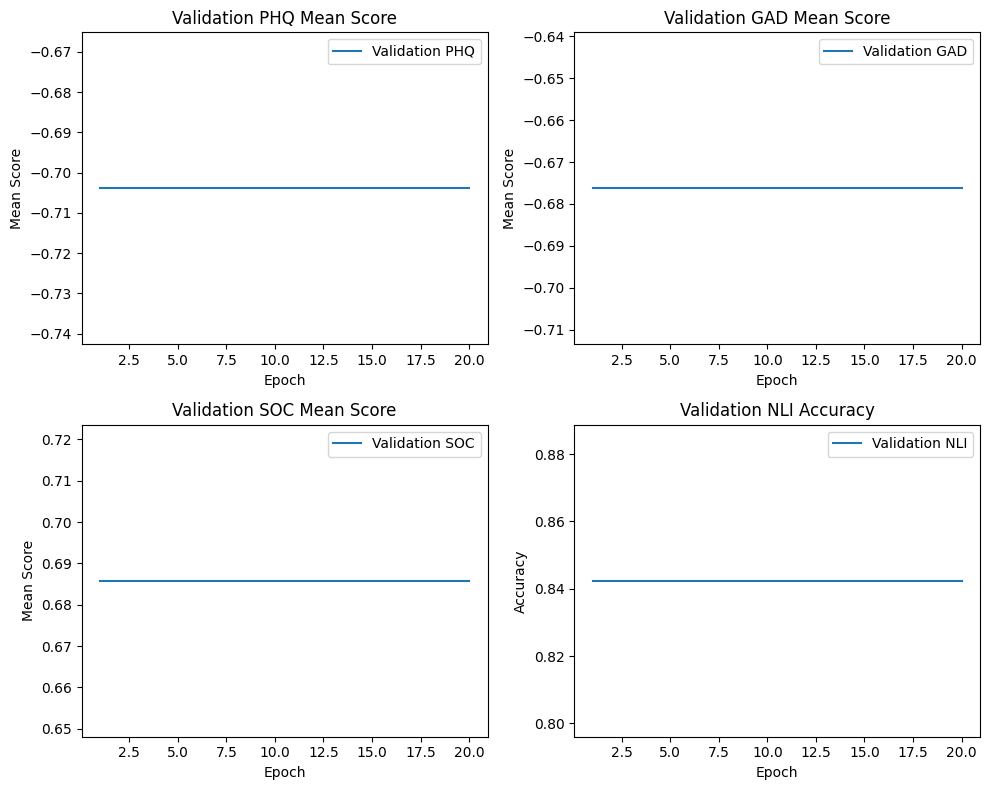

In [61]:
mean_scores = {
    'validation_gad': [],
    'validation_soc': [],
    'validation_phq': [],
    'nli' : []
}

for p in tqdm(pipelines, desc="Training Epochs"):
    print('pipline: {}'.format(p))
    mnli_checkpoint = pipeline("zero-shot-classification", str(Path(p)), device=device)
    mnli_checkpoint.model_identifier = str(Path(p))

    nli_accuracy(mnli_checkpoint, validation_dataset)
        
    validate(mnli_checkpoint, questions_gad, 0, 'validation_gad')
    
    validate(mnli_checkpoint, questions_soc, 0, 'validation_soc')
    
    validate(mnli_checkpoint, questions_phq, 0, 'validation_phq')
    
    torch.cuda.empty_cache()
      
plot_mean_scores(mean_scores, 20)

# Train 109 MNLI models

In [37]:
# mnli_pipelines = [
#                     'typeform/distilbert-base-uncased-mnli',
#                     'ishan/distilbert-base-uncased-mnli',
#                     'typeform/mobilebert-uncased-mnli',
#                     'typeform/squeezebert-mnli',
#                     'cross-encoder/nli-roberta-base',
#                     'cross-encoder/nli-deberta-base',
#                     'cross-encoder/nli-distilroberta-base',
#                     'cross-encoder/nli-MiniLM2-L6-H768',
#                     'navteca/bart-large-mnli',
#                     'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
#                     'joeddav/bart-large-mnli-yahoo-answers',
#                     'Narsil/deberta-large-mnli-zero-cls',
#                     'seduerr/paiintent',
#                     'microsoft/deberta-large-mnli',
#                     'microsoft/deberta-base-mnli',
#                     'ishan/bert-base-uncased-mnli',
#                     'Alireza1044/albert-base-v2-mnli',
#                     'Intel/bert-base-uncased-mnli-sparse-70-unstructured',
#                     'yoshitomo-matsubara/bert-large-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
#                     'valhalla/distilbart-mnli-12-6',
#                     'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
#                     'cross-encoder/nli-deberta-v3-base',
#                     'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
#                     'tasksource/deberta-small-long-nli',
#                     'joeddav/xlm-roberta-large-xnli',
#                     'MoritzLaurer/DeBERTa-v3-xsmall-mnli-fever-anli-ling-binary',
#                     'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli',
#                     'cross-encoder/nli-deberta-v3-xsmall',
#                     'cross-encoder/nli-deberta-v3-large',
#                     'sileod/deberta-v3-base-tasksource-nli',
#                     'MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli',
#                     'sileod/deberta-v3-large-tasksource-nli',
#                     'MoritzLaurer/DeBERTa-v3-base-mnli',
#                     'Narsil/deberta-large-mnli-zero-cls',
#                     'mjwong/multilingual-e5-base-xnli-anli',
#                     'sjrhuschlee/flan-t5-base-mnli',
# ]

In [41]:
mnli_pipelines = [
                    'typeform/distilbert-base-uncased-mnli',
#                     'typeform/mobilebert-uncased-mnli',
                    'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
#                     'Alireza1044/albert-base-v2-mnli',
#                     'yoshitomo-matsubara/bert-large-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
                    'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
                    'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
                    'tasksource/deberta-small-long-nli',
                    'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli',
                    'sileod/deberta-v3-base-tasksource-nli',
                    'MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli',
                    'sileod/deberta-v3-large-tasksource-nli',
                    'MoritzLaurer/DeBERTa-v3-base-mnli',
                    'mjwong/multilingual-e5-base-xnli-anli',
                    'sjrhuschlee/flan-t5-base-mnli',  
]

In [3]:
from pathlib import Path

In [43]:
# pipelines = [str(a) for a in Path('/dt/puzis/cnalab/maor/mnli_models/').glob('*bgu_mnli')]

In [44]:
len(mnli_pipelines)

12

In [49]:
from datasets import load_dataset
dataset = load_dataset('multi_nli')

validation_dataset = dataset['validation_matched']

In [41]:
questions_gad = [
    GAD7Q1s, GAD7Q2s, GAD7Q3s, GAD7Q4s, GAD7Q5s, GAD7Q6s, GAD7Q7s,
]

questions_soc = [
    SOCQ4s, SOCQ5s, SOCQ6s, SOCQ8s, SOCQ9s, SOCQ12s, SOCQ16s, SOCQ19s,
    SOCQ21s, SOCQ25s, SOCQ26s, SOCQ28s, SOCQ29s,
]

questions_phq = [PHQ9Q1s , PHQ9Q2s , PHQ9Q3s , PHQ9Q4s , PHQ9Q5s , PHQ9Q6s , PHQ9Q7s , PHQ9Q8s , PHQ9Q9s]


questions_pg = questions_phq + questions_gad

In [42]:
questions_neuro = [BIG5Q13s , BIG5Q14s]

In [47]:
def train(pipeline, questions, epoch, i):
    pipeline.model.train()
    pipeline.model_identifier = p + f'_epoch_{epoch}'
    
    for Q in questions:
        q = Q[i]
        q.run(pipeline)
        effect_size = q.effect_size() * -1
        effect_size = effect_size.to(device)       
        
        optimizer.zero_grad()
        effect_size.backward()
        optimizer.step()
    return pipeline.model

In [48]:
epochs = 21
base_path = Path('/dt/puzis/cnalab/karina/mnli_models/hugging_face/version4')

train_q_list = [
#     (questions_phq, 'q_phq'),
#     (questions_gad, 'q_gad'),
#     (questions_pg, 'q_phq_gad'),
    (questions_soc, 'q_soc'),
]

for p in tqdm(mnli_pipelines, desc="Training Pipelines"):
#     if ( p == '/dt/puzis/cnalab/maor/mnli_models/ufal_robeczech-base_bgu_mnli'):
#         continue
#     config_path = Path(p) / 'config.json'
#     if not config_path.is_file():
#         print(f"Skipping pipeline {p}: config.json not found.")
#         continue
    print('pipline: {}'.format(p))
    
    mnli_checkpoint = pipeline("zero-shot-classification", p, device=device)
    mnli_checkpoint.model_identifier = p
    tokenizer = mnli_checkpoint.tokenizer
    optimizer = AdamW(mnli_checkpoint.model.parameters(), lr=2e-5, weight_decay=0.01)
    
    for questionnaire, suffix in tqdm(train_q_list):
        print(suffix)
        output_dir = base_path / f'mlm_st_{p.replace("/", "")}_{suffix}/'
        output_dir.mkdir(parents=True, exist_ok=True) 
        
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            print('Epoch: {}'.format(epoch))
            if epoch == 0:
                epoch_dir = output_dir / f'checkpoint_epoch_{epoch}'
                mnli_checkpoint.model.save_pretrained(epoch_dir, verbose=False)
                tokenizer.save_pretrained(epoch_dir, verbose=False)
            else:      
                train(mnli_checkpoint, questionnaire, epoch, 0)
                epoch_dir = output_dir / f'checkpoint_epoch_{epoch}'
                mnli_checkpoint.model.save_pretrained(epoch_dir, verbose=False)
                tokenizer.save_pretrained(epoch_dir, verbose=False)
            
            torch.cuda.empty_cache()



Training Pipelines:   0%|          | 0/12 [00:00<?, ?it/s]

pipline: typeform/distilbert-base-uncased-mnli


The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprec

q_soc




Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

...



Training Epochs:  95%|█████████▌| 20/21 [01:36<00:04,  4.88s/it]

Epoch: 20


T5ForSequenceClassification(
  (transformer): T5Model(
    (shared): Embedding(32128, 768)
    (encoder): T5Stack(
      (embed_tokens): Embedding(32128, 768)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=768, out_features=768, bias=False)
                (k): Linear(in_features=768, out_features=768, bias=False)
                (v): Linear(in_features=768, out_features=768, bias=False)
                (o): Linear(in_features=768, out_features=768, bias=False)
                (relative_attention_bias): Embedding(32, 12)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseGatedActDense(
                (wi_0): Linear(in_features=768, out_features=2048, bias=False)
                (wi_1): Linea

('/dt/puzis/cnalab/karina/mnli_models/hugging_face/version4/mlm_st_sjrhuschleeflan-t5-base-mnli_q_soc/checkpoint_epoch_20/tokenizer_config.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/version4/mlm_st_sjrhuschleeflan-t5-base-mnli_q_soc/checkpoint_epoch_20/special_tokens_map.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/version4/mlm_st_sjrhuschleeflan-t5-base-mnli_q_soc/checkpoint_epoch_20/spiece.model',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/version4/mlm_st_sjrhuschleeflan-t5-base-mnli_q_soc/checkpoint_epoch_20/added_tokens.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/version4/mlm_st_sjrhuschleeflan-t5-base-mnli_q_soc/checkpoint_epoch_20/tokenizer.json')



Training Epochs: 100%|██████████| 21/21 [01:41<00:00,  4.84s/it]

Training Pipelines: 100%|██████████| 12/12 [23:12<00:00, 116.01s/it]


In [43]:
import gc
gc.collect()
torch.cuda.empty_cache()

120

# Validate 109 MNLI models

In [44]:
from pathlib import Path

In [45]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2').glob('*q_*')]

In [46]:
# pipelines = sorted(pipelines, key=lambda x: int(x.split('epoch-')[1]))
pipelines


['/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_phq',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_soc',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_digitalepidemiologylabcovid-twitter-bert-v2-mnli_q_phq',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_digitalepidemiologylabcovid-twitter-bert-v2-mnli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_digitalepidemiologylabcovid-twitter-bert-v2-mnli_q_soc',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-base-mnli-fever-anli_q_phq',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-base-mnli-fever-anli_q_gad',
 '/dt/puzis/cn

In [47]:
len(pipelines)

36

In [48]:
def validate(epoch, model, questions, i, key):
    total_effect_size = 0
    model.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
            total_effect_size += q.effect_size()
        
    avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key][epoch].append(avg_val_mean_score)

In [51]:
def nli_accuracy(model, validation_data = validation_dataset):
    correct = 0
    total = 0
    model.model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = model.tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    return accuracy

In [58]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        
        if key == 'nli':
            range_plot = [0,1,10,20]
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            range_plot = list(range(21))
            plt.title(f'{titles[idx]} Mean Score')
            plt.ylabel('Mean Score')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

In [4]:
import csv
import os

result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path) 
    
output_path = result_path / f'hf_all_q_mean_score_v2_nli.csv'

In [ ]:
from typing import Dict, List

epochs = 21

mean_scores: Dict[str, Dict[str, List[float]]] = {
#     'validation_gad': {str(i): [] for i in range(epochs)},
#     'validation_soc': {str(i): [] for i in range(epochs)},
#     'validation_phq': {str(i): [] for i in range(epochs)},
#     'validation_neuro': {str(i): [] for i in range(epochs)},
    'nli': {str(i): [] for i in [0, 1, 10, 20]},
}
    
# Writing to CSV after each pipeline
with open(output_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write header row
    header = ['questionnaire', 'model'] + [str(i) for i in range(epochs)]
    writer.writerow(header)
    

    for p in tqdm(pipelines, desc="pipelines"):
        print('pipline: {}'.format(p))
#         if (p == "/dt/puzis/cnalab/maor/mnli_models/airesearch_wangchanberta-base-att-spm-uncased_bgu_mnli"):
#             continue
        
        folder_path = Path(p)
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            checkpoint_path = folder_path / f'checkpoint_epoch_{epoch}'
    #         checkpoint_path = folder_path
            print(str(Path(checkpoint_path)))
            mnli_checkpoint = pipeline("zero-shot-classification", str(Path(checkpoint_path)), device=device)
            mnli_checkpoint.model_identifier = str(Path(checkpoint_path))

            if epoch in [0, 1, 10, 20]:
                print(f"Epoch {epoch + 1} - NLI Accuracy Validation")
                accuracy = nli_accuracy(mnli_checkpoint)  # Replace with your NLI validation function
                mean_scores['nli'][str(epoch)].append(accuracy)

#             validate(str(epoch), mnli_checkpoint, questions_gad, 0, 'validation_gad')
#             validate(str(epoch), mnli_checkpoint, questions_soc, 0, 'validation_soc')
#             validate(str(epoch), mnli_checkpoint, questions_phq, 0, 'validation_phq')
#             validate(str(epoch), mnli_checkpoint, questions_neuro, 0, 'validation_neuro')


            torch.cuda.empty_cache()
        # Prepare rows for writing
#         for questionnaire, data in mean_scores.items():
#             row = [
#                 questionnaire, p,
#                 *[
#                     data[str(i)][-1].item() if data[str(i)] else 'N/A'
#                     for i in range(epochs)
#                 ]
#             ]
#             writer.writerow(row)
        for questionnaire, data in mean_scores.items():
            row = [questionnaire, p] + [data[str(i)][-1] if data[str(i)] else 'N/A' for i in [0, 1, 10, 20]]
            writer.writerow(row)

        # Clear mean_scores after each pipeline to avoid duplicate data
        mean_scores = {
#             'validation_gad': {str(i): [] for i in range(epochs)},
#             'validation_soc': {str(i): [] for i in range(epochs)},
#             'validation_phq': {str(i): [] for i in range(epochs)},
#             'validation_neuro': {str(i): [] for i in range(epochs)},
            'nli': {str(i): [] for i in [0, 1, 10, 20]},
        }


74


pipelines:   0%|          | 0/36 [00:00<?, ?it/s]

pipline: /dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_phq



Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_phq/checkpoint_epoch_0
Epoch 1 - NLI Accuracy Validation


...

/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-large-mnli-fever-anli-ling-wanli_q_gad/checkpoint_epoch_8



Training Epochs:  43%|████▎     | 9/21 [14:21<05:45, 28.76s/it]

/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-large-mnli-fever-anli-ling-wanli_q_gad/checkpoint_epoch_9



Training Epochs:  48%|████▊     | 10/21 [14:33<04:18, 23.46s/it]

/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-large-mnli-fever-anli-ling-wanli_q_gad/checkpoint_epoch_10
Epoch 11 - NLI Accuracy Validation


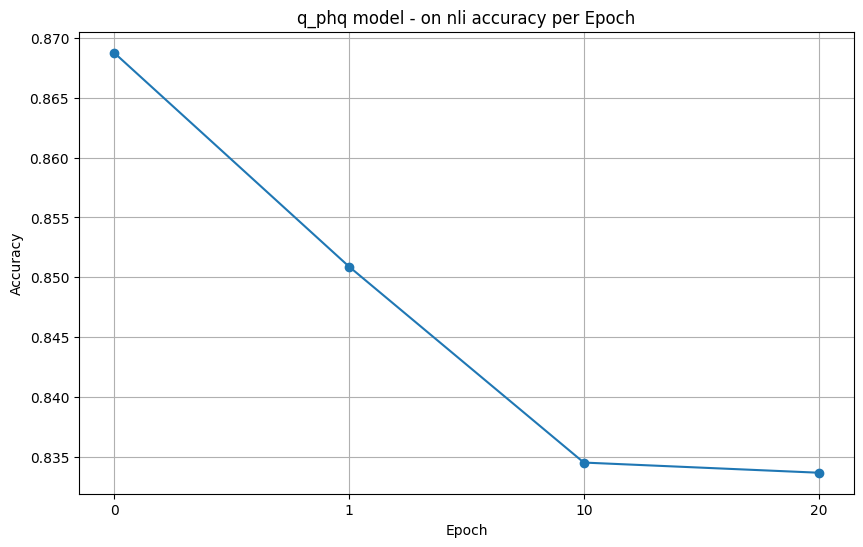

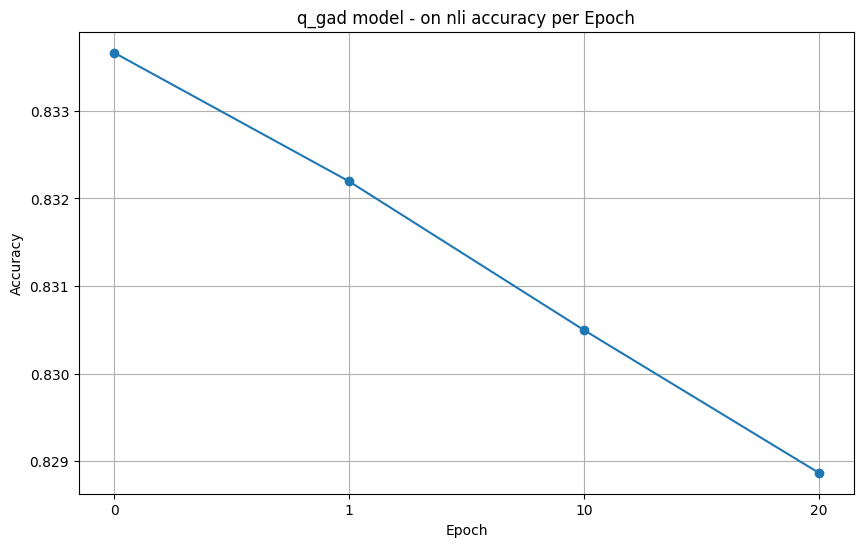

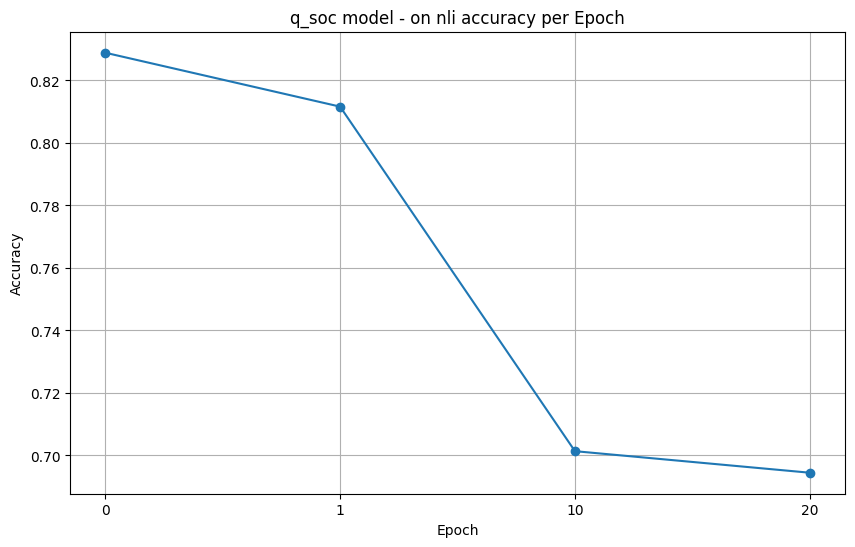

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
# csv_path = '/path/to/your/csvfile.csv'  # Replace with your CSV file path
data = pd.read_csv(output_path)
# data = data[data['model'].isin(models_list)]

# Define model types and validation types
model_types = ['q_phq', 'q_gad', 'q_soc']
# model_types = ['q_soc']
# validation_types = ['validation_gad', 'validation_phq', 'validation_soc', 'validation_neuro']
validation_types = ['nli']
# validation_types = ['validation_neuro']
# validation_types = ['validation_soc']

# Loop through each model type and validation type to calculate mean and create plots
for model_type in model_types:
    for validation_type in validation_types:
        # Filter data for the specific model type and validation type
        filtered_data = data[data['model'].str.contains(model_type) & (data['questionnaire'] == validation_type)]
        
        # Drop columns 'questionnaire' and 'model' to focus only on epochs
        epoch_data = filtered_data.drop(columns=['questionnaire', 'model'])
        
        # Calculate the mean score for each epoch across all rows
        mean_scores = epoch_data.mean(axis=0)
        
        # Plot the mean score over epochs
        plt.figure(figsize=(10, 6))
        plt.plot(mean_scores.index, mean_scores.values, marker='o', linestyle='-')
        plt.title(f'{model_type} model - on {validation_type} accuracy per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.grid(True)
        
        # Save the plot with a descriptive filename
        plt.savefig(result_path / f'{model_type}_{validation_type}_mean_score_v2.png')
        
        # Optionally, display the plot
        plt.show()


In [32]:
# models_list = data['model'].tolist()

In [39]:
# data

In [58]:
# mean_mean_scores = {
#     'validation_gad': [],
#     'validation_soc': [],
#     'validation_phq': [],
#     'nli' : []
# }


# for key, inner_dict in mean_scores.items():
#     if inner_dict:  # Check if the inner dictionary is not empty
#         for score_list in inner_dict.values():
#             # Calculate the average of the current score list
#             if score_list:  # Ensure the list is not empty
#                 mean = sum(score_list) / len(score_list)
#                 mean_mean_scores[key].append(mean)

In [75]:
# plot_mean_scores(mean_mean_scores, 21)

In [76]:
# mean_scores